In [1]:
import pandas as pd

df = pd.read_csv("/mnt/c/Users/gursi/Downloads/archive/modified_data.csv")

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [3]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   str    
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   str    
 15  city            4600 non-null   str    
 16  statezip        4600 non-null   str    
 17  price_per_sqft  4600 non-null   float64
dtyp

In [8]:
df.columns.tolist()

['date',
 'price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'sqft_above',
 'sqft_basement',
 'yr_built',
 'yr_renovated',
 'street',
 'city',
 'statezip',
 'price_per_sqft']

In [9]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 322875.0
Q3: 654962.5
IQR: 332087.5
Lower Bound: -175256.25
Upper Bound: 1153093.75


In [10]:
outliers = df[
    (df["price"] < lower_bound) |
    (df["price"] > upper_bound)
]

outliers

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
1,2014-05-02,2384000.00,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
11,2014-05-02,1400000.00,4.0,2.50,2920,4000,1.5,0,0,5,1910,1010,1909,1988,3838-4098 44th Ave NE,Seattle,WA 98105,479.45
14,2014-05-02,1200000.00,5.0,2.75,2910,9480,1.5,0,0,3,2910,0,1939,1969,3534 46th Ave NE,Seattle,WA 98105,412.37
99,2014-05-05,1395000.00,5.0,3.50,4010,8510,2.0,0,1,5,2850,1160,1971,0,3930 NE Belvoir Pl,Seattle,WA 98105,347.88
122,2014-05-05,2280000.00,7.0,8.00,13540,307752,3.0,0,4,3,9410,4130,1999,0,26408 NE 70th St,Redmond,WA 98053,168.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4348,2014-05-05,2199900.00,4.0,1.50,1120,5427,1.0,0,0,3,1120,0,1969,2014,19009-19021 SE 266th St,Covington,WA 98042,1964.20
4350,2014-07-03,26590000.00,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,22533.90
4465,2014-06-05,2560498.33,3.0,2.50,1710,1664,2.0,0,0,5,1300,410,2003,0,2826 21st Ave W,Seattle,WA 98199,1497.37
4467,2014-06-06,1337044.20,4.0,3.50,4280,9583,2.0,0,0,3,4280,0,2005,0,1415 108th Ave SE,Bellevue,WA 98004,312.39


In [11]:
import pandas as pd

# Select only numerical columns
numeric_df = df.select_dtypes(include="number")

summary = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Std Dev": numeric_df.std(),
    "Variance": numeric_df.var(),
    "Min": numeric_df.min(),
    "Q1 (25%)": numeric_df.quantile(0.25),
    "Q2 (50%)": numeric_df.quantile(0.50),
    "Q3 (75%)": numeric_df.quantile(0.75),
    "Max": numeric_df.max()
})

summary["IQR"] = summary["Q3 (75%)"] - summary["Q1 (25%)"]

summary.round(2)

,Mean,Median,Std Dev,Variance,Min,Q1 (25%),Q2 (50%),Q3 (75%),Max,IQR
price,551962.99,460943.46,563834.70,3.179096e+11,0.0,322875.00,460943.46,654962.50,26590000.0,332087.50
bedrooms,3.40,3.00,0.91,8.300000e-01,0.0,3.00,3.00,4.00,9.0,1.00
bathrooms,2.16,2.25,0.78,6.100000e-01,0.0,1.75,2.25,2.50,8.0,0.75
sqft_living,2139.35,1980.00,963.21,9.277676e+05,370.0,1460.00,1980.00,2620.00,13540.0,1160.00
sqft_lot,14852.52,7683.00,35884.44,1.287693e+09,638.0,5000.75,7683.00,11001.25,1074218.0,6000.50
floors,1.51,1.50,0.54,2.900000e-01,1.0,1.00,1.50,2.00,3.5,1.00
waterfront,0.01,0.00,0.08,1.000000e-02,0.0,0.00,0.00,0.00,1.0,0.00
view,0.24,0.00,0.78,6.100000e-01,0.0,0.00,0.00,0.00,4.0,0.00
condition,3.45,3.00,0.68,4.600000e-01,1.0,3.00,3.00,4.00,5.0,1.00
sqft_above,1827.27,1590.00,862.17,7.433353e+05,370.0,1190.00,1590.00,2300.00,9410.0,1110.00


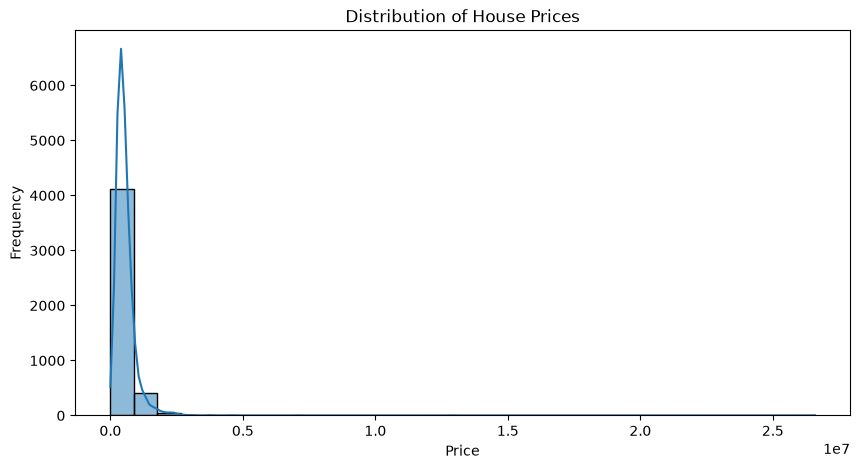

In [12]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

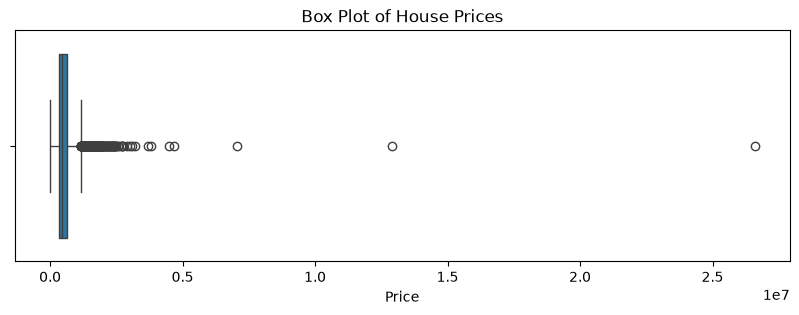

In [13]:
plt.figure(figsize=(10,3))

sns.boxplot(x=df["price"])

plt.title("Box Plot of House Prices")
plt.xlabel("Price")

plt.show()

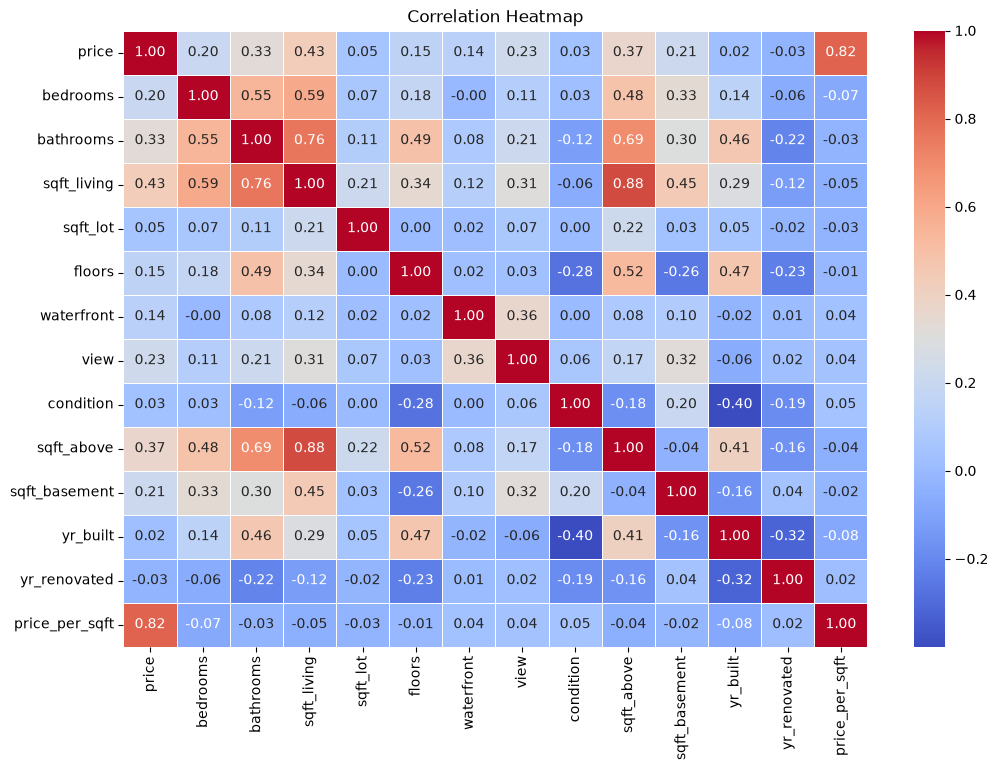

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

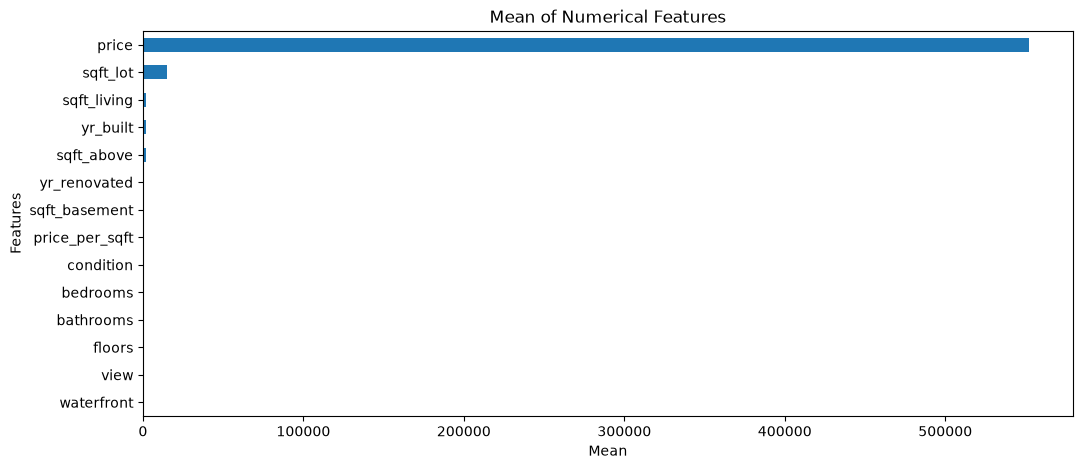

In [15]:
plt.figure(figsize=(12,5))

summary["Mean"].sort_values().plot(kind="barh")

plt.title("Mean of Numerical Features")
plt.xlabel("Mean")
plt.ylabel("Features")

plt.show()

In [16]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

In [17]:
encoded_df = pd.get_dummies(
    df,
    columns=["street", "city", "statezip"],
    drop_first=True
)

encoded_df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,False,False,False,False,False,False,False,False,False,False
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,...,False,False,False,False,False,False,False,False,False,False
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df.isnull().sum().sort_values(ascending=False)

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
year              0
month             0
dtype: int64

In [19]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


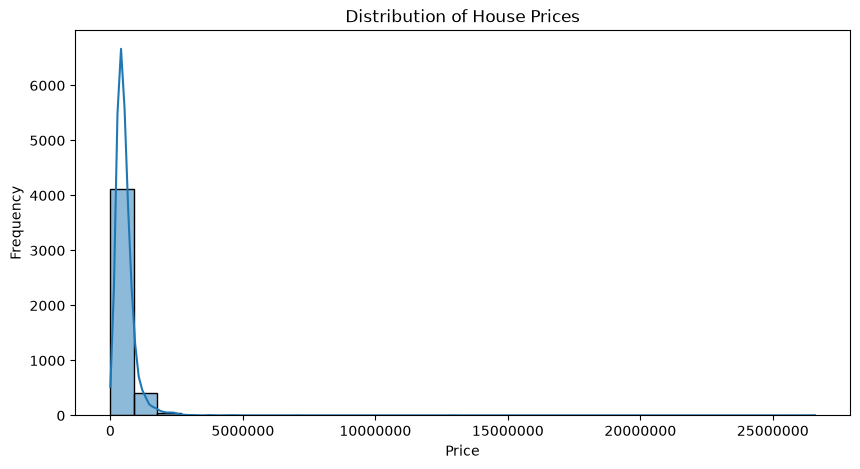

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(df["price"], bins=30, kde=True)

plt.ticklabel_format(style="plain", axis="x")

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

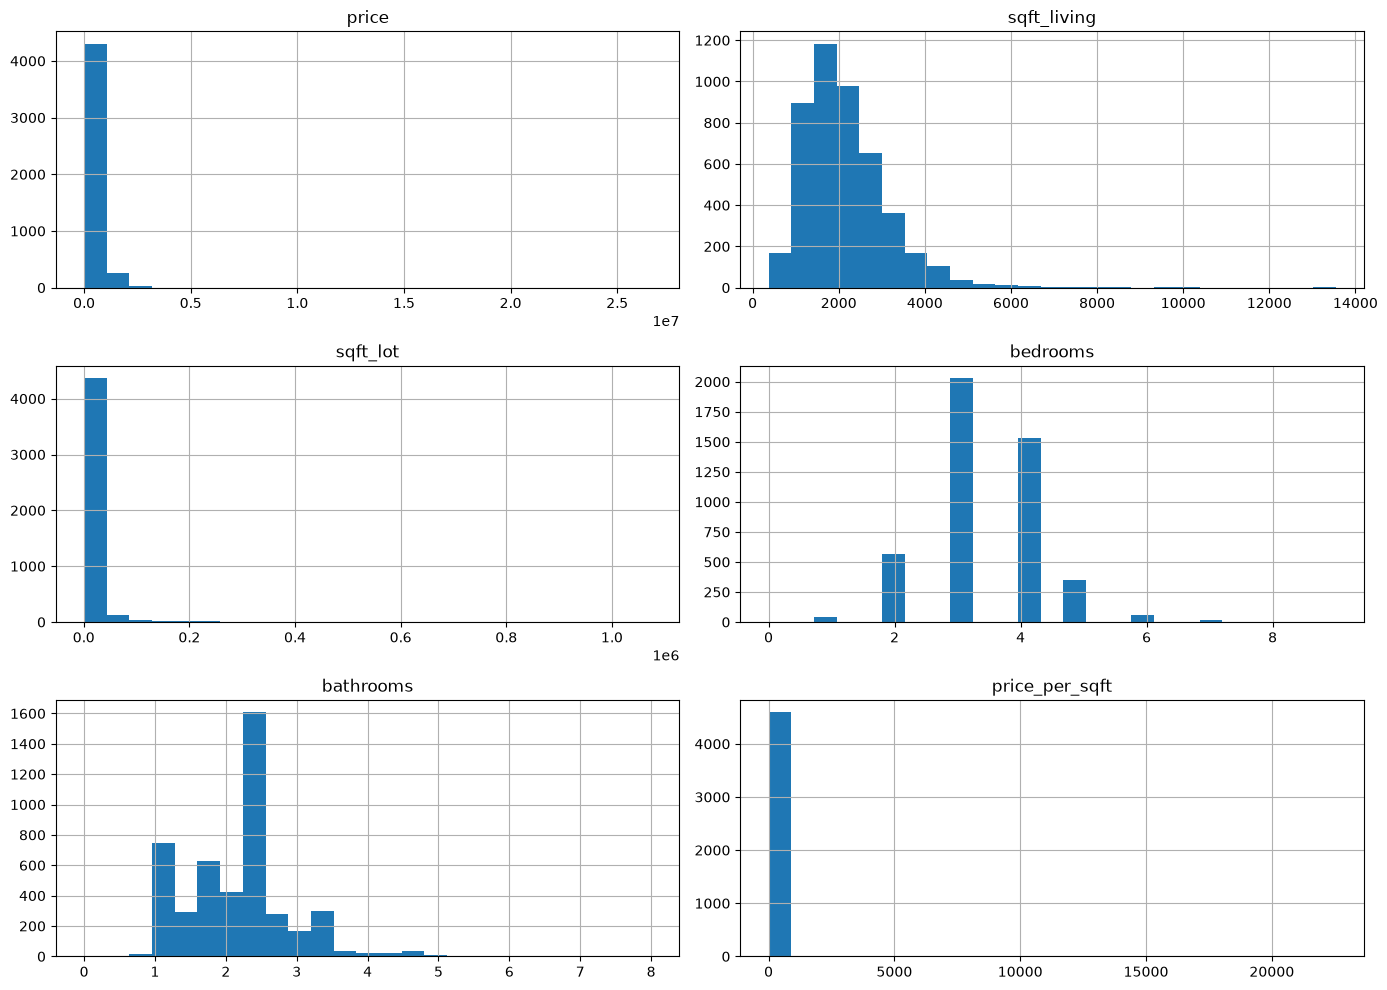

In [21]:
numeric_cols = [
    "price",
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms",
    "price_per_sqft"
]

df[numeric_cols].hist(
    figsize=(14,10),
    bins=25
)

plt.tight_layout()
plt.show()

In [22]:
df[["city","statezip","street"]].nunique()

city          44
statezip      77
street      4525
dtype: int64

In [23]:
df = df.drop(columns="street")

In [24]:
df.groupby("city")["price"].agg(["count","mean"]).sort_values("mean", ascending=False)

,count,mean
city,,
Medina,11,2.046559e+06
Clyde Hill,11,1.321945e+06
Yarrow Point,4,1.194838e+06
Mercer Island,86,1.123818e+06
Bellevue,286,8.471807e+05
Beaux Arts Village,1,7.450000e+05
Fall City,11,6.926818e+05
Sammamish,175,6.869176e+05
Redmond,235,6.676495e+05


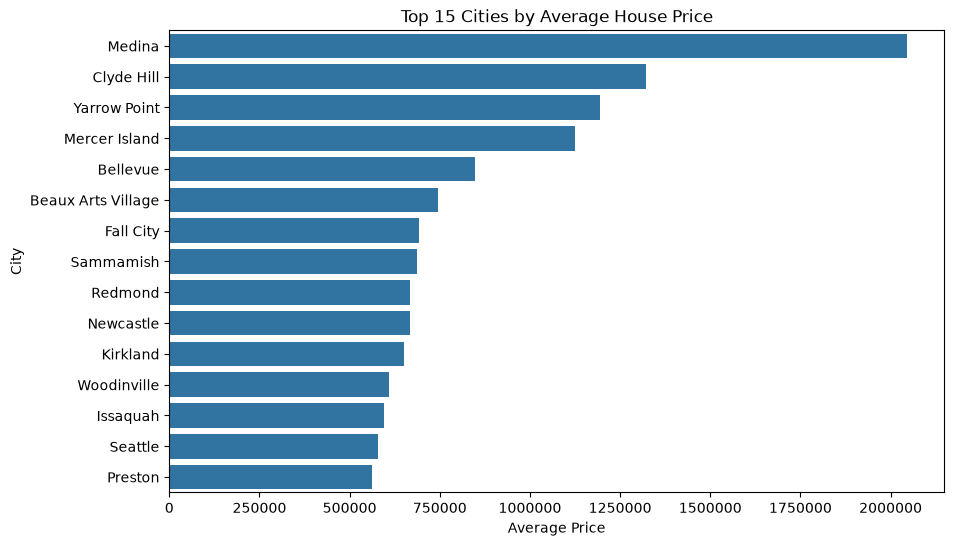

In [25]:
city_price = (
    df.groupby("city")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=city_price.values,
    y=city_price.index
)

plt.ticklabel_format(style="plain", axis="x")

plt.title("Top 15 Cities by Average House Price")
plt.xlabel("Average Price")
plt.ylabel("City")

plt.show()

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("/mnt/c/Users/gursi/Downloads/archive/modified_data.csv")

print(df.shape)
df.head()

(4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [7]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df = df.drop(columns=["date", "street"])

In [8]:
df = pd.get_dummies(
    df,
    columns=["city", "statezip"],
    drop_first=True
)

In [9]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

print("Original:", df.shape)
print("Cleaned :", df_clean.shape)

Original: (4600, 135)
Cleaned : (4360, 135)


In [10]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (4360, 134)
y Shape: (4360,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)
print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

Training Feature Shape: (3488, 134)
Testing Feature Shape : (872, 134)
Training Target Shape : (3488,)
Testing Target Shape  : (872,)


In [12]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
y_pred = model.predict(X_test)

print("First 5 Predictions:")
print(y_pred[:5])

First 5 Predictions:
[600384.39841329 644724.71576069 819811.61980399 678198.07791525
 537987.18057541]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:,.2f}")
print(f"MSE : {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MAE : 53,552.23
MSE : 7,410,762,017.28
RMSE: 86,085.78
R² Score: 0.8504


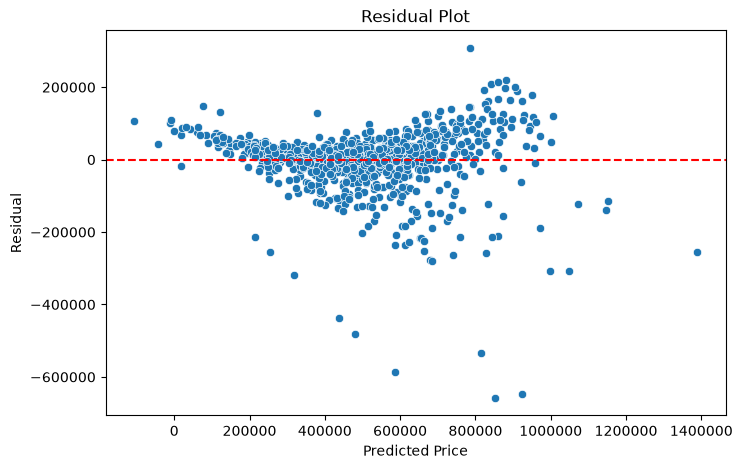

In [15]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color="red", linestyle="--")

plt.ticklabel_format(style="plain")

plt.title("Residual Plot")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.show()

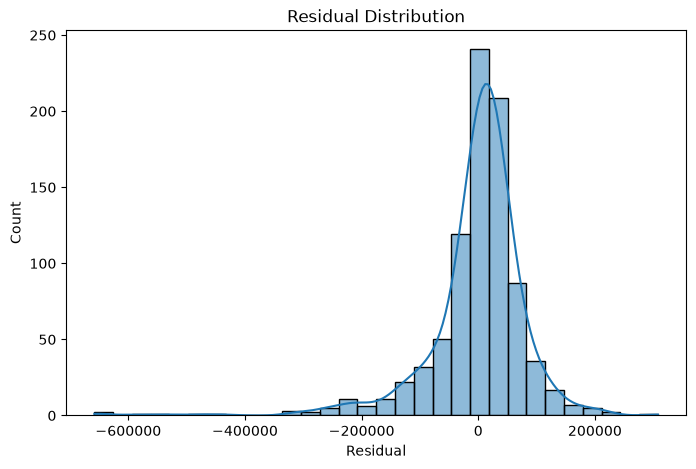

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, bins=30, kde=True)

plt.title("Residual Distribution")
plt.xlabel("Residual")

plt.show()

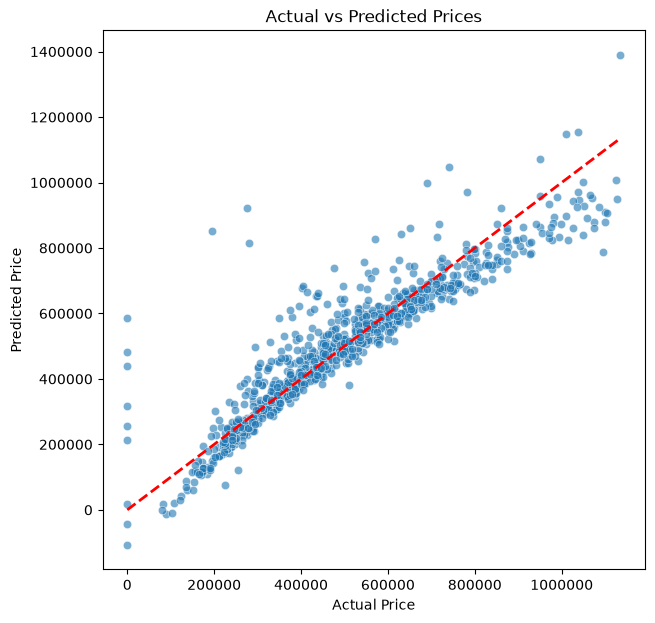

In [17]:
plt.figure(figsize=(7,7))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2
)

plt.ticklabel_format(style="plain")

plt.title("Actual vs Predicted Prices")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.show()

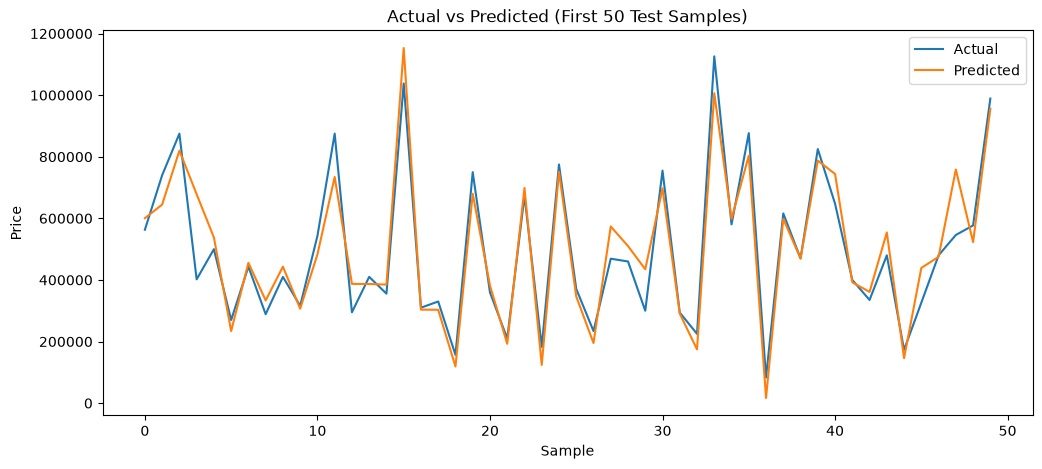

In [18]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
}).reset_index(drop=True)

plt.figure(figsize=(12,5))

plt.plot(comparison["Actual"][:50], label="Actual")
plt.plot(comparison["Predicted"][:50], label="Predicted")

plt.ticklabel_format(style="plain")

plt.title("Actual vs Predicted (First 50 Test Samples)")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()

plt.show()